# ifBO vs. Random Search: Wallclock Savings to Reach Target Accuracy

Quantifies the headline claim *"reaches target accuracy using ~X% less
wallclock time than random search"* using the 20-trial HPO logs in
`sample-results/all_results/`.

Scope: the four **practice** datasets — `ag_news`, `amazon`, `dbpedia`,
`imdb` — each with a `<ds>_random.jsonl` (Random Search) and `<ds>_ifbo.jsonl`
(ifBO, the flagship freeze-thaw BO optimizer) run. The held-out exam dataset
`yelp` is excluded since it isn't used to score this claim.

**Methodology**

1. For each dataset, define the *target accuracy* as the best validation
   accuracy Random Search ever reaches within its 20-trial budget (i.e. the
   accuracy level both optimizers are compared against reaching).
2. Reconstruct each run's cumulative wallclock time from consecutive trial
   timestamps (same convention as `final_results_analysis.ipynb`).
3. Find the first wallclock time at which each optimizer's running-best
   incumbent reaches the target accuracy.
4. Report the relative time saved: `(random_time - ifbo_time) / random_time`.

Each `.jsonl` line is one completed trial:
`{config, seed, budget, trialNo, execution_time, timestamp, val_error, best_so_far, epoch_history}`.

In [1]:
import json
import math
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

RESULTS_DIR = Path("all_results")

# Practice datasets only -- `yelp` is the held-out exam set and isn't part
# of this claim.
DATASETS = {
    "ag": "AG News",
    "amzn": "Amazon",
    "db": "DBpedia",
    "imdb": "IMDB",
}

OPTIMIZERS = {
    "ifbo": "ifBO",
    "random": "Random Search",
}

# Same categorical colors as final_results_analysis.ipynb, kept fixed per
# optimizer across every figure below.
COLORS = {
    "ifbo": "#2a78d6",  # blue
    "random": "#1baf7a",  # aqua
}

GRID_NCOLS = 2
GRID_NROWS = math.ceil(len(DATASETS) / GRID_NCOLS)


def dataset_grid(**subplots_kwargs):
    fig, axes = plt.subplots(GRID_NROWS, GRID_NCOLS, **subplots_kwargs)
    axes_flat = np.atleast_1d(axes).flatten()
    for ax in axes_flat[len(DATASETS) :]:
        ax.set_visible(False)
    return fig, axes_flat[: len(DATASETS)]

## Load trial histories

In [2]:
TIMESTAMP_FMT = "%Y%m%d_%H%M%S,%f"


def load_trials(path: Path) -> list[dict]:
    trials = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                trials.append(json.loads(line))
    trials.sort(key=lambda t: datetime.strptime(t["timestamp"], TIMESTAMP_FMT))
    return trials


raw_trials: dict[tuple[str, str], list[dict]] = {}
rows = []

for ds_key in DATASETS:
    for opt_key in OPTIMIZERS:
        path = RESULTS_DIR / f"{ds_key}_{opt_key}.jsonl"
        trials = load_trials(path)
        raw_trials[(ds_key, opt_key)] = trials

        t0 = datetime.strptime(trials[0]["timestamp"], TIMESTAMP_FMT)
        running_best = float("inf")
        for t in trials:
            ts = datetime.strptime(t["timestamp"], TIMESTAMP_FMT)
            running_best = min(running_best, t["val_error"])
            rows.append(
                {
                    "dataset": ds_key,
                    "optimizer": opt_key,
                    "trialNo": t["trialNo"],
                    "wallclock_s": (ts - t0).total_seconds(),
                    "val_accuracy": 1.0 - t["val_error"],
                    "best_val_accuracy_so_far": 1.0 - running_best,
                }
            )

trials_df = pd.DataFrame(rows)
trials_df["dataset_label"] = trials_df["dataset"].map(DATASETS)
trials_df["optimizer_label"] = trials_df["optimizer"].map(OPTIMIZERS)
trials_df.head()

,dataset,optimizer,trialNo,wallclock_s,val_accuracy,best_val_accuracy_so_far,dataset_label,optimizer_label
0,ag,ifbo,1,0.000000,0.2500,0.2500,AG News,ifBO
1,ag,ifbo,2,176.333736,0.7565,0.7565,AG News,ifBO
2,ag,ifbo,3,283.719731,0.7630,0.7630,AG News,ifBO
3,ag,ifbo,4,470.781416,0.2500,0.7630,AG News,ifBO
4,ag,ifbo,5,528.866625,0.9060,0.9060,AG News,ifBO


## 1. Target accuracy per dataset

Target = the best validation accuracy Random Search reaches anywhere in its
20-trial run (both optimizers exceed this, so it's a fair bar for "the
accuracy random search eventually gets to").

In [3]:
target_acc = (
    trials_df[trials_df["optimizer"] == "random"]
    .groupby("dataset")["val_accuracy"]
    .max()
    .rename("target_accuracy")
)
target_acc.index = target_acc.index.map(DATASETS)
target_acc.to_frame()

,target_accuracy
dataset,
AG News,0.8965
Amazon,0.7925
DBpedia,0.9780
IMDB,0.8670


## 2. Best accuracy vs. wallclock time, with target marked

Faint dots are individual trials; the step line is the running best-so-far
incumbent. The dashed horizontal line is the target accuracy from above.

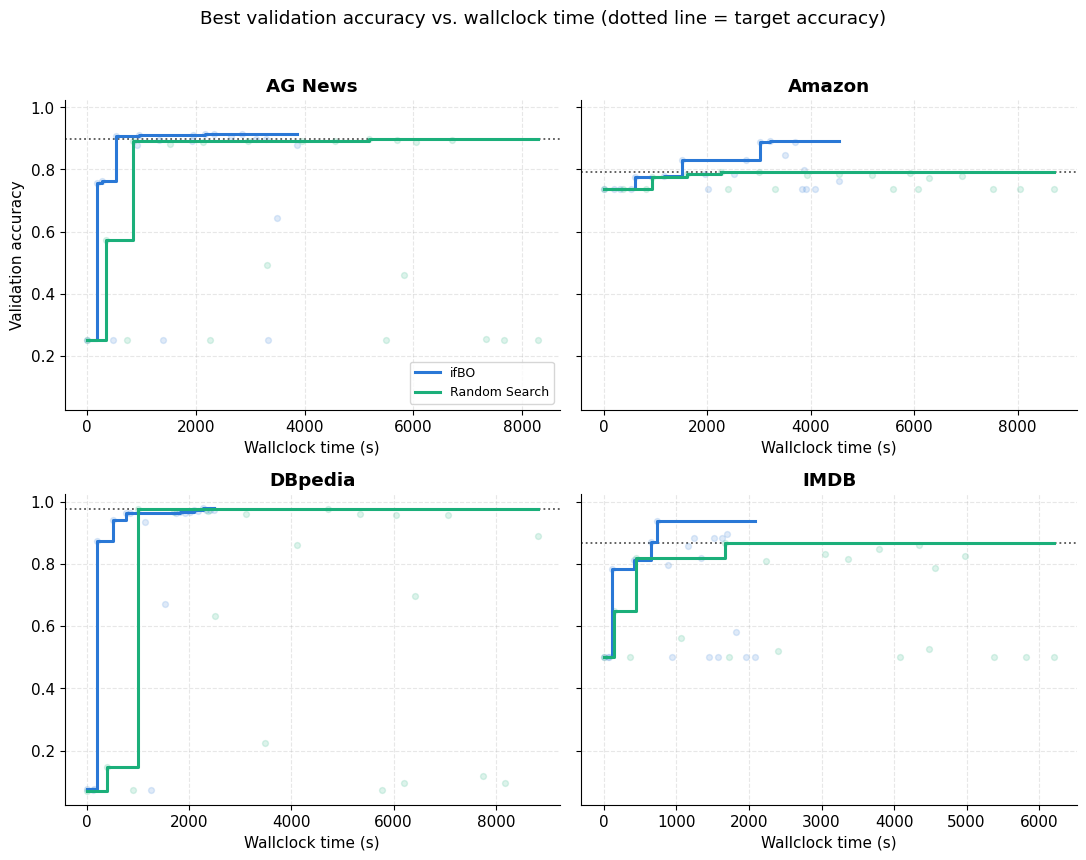

In [4]:
fig, axes = dataset_grid(figsize=(5.5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, (ds_key, ds_label) in zip(axes, DATASETS.items()):
    sub_ds = trials_df[trials_df["dataset"] == ds_key]
    for opt_key, opt_label in OPTIMIZERS.items():
        sub = sub_ds[sub_ds["optimizer"] == opt_key].sort_values("wallclock_s")
        if sub.empty:
            continue
        color = COLORS[opt_key]
        ax.scatter(sub["wallclock_s"], sub["val_accuracy"], color=color, alpha=0.15, s=18, zorder=1)
        ax.step(
            sub["wallclock_s"], sub["best_val_accuracy_so_far"], where="post",
            color=color, linewidth=2.2, label=opt_label, zorder=2,
        )
    ax.axhline(target_acc[ds_label], color="#555555", linestyle=":", linewidth=1.3, zorder=0)
    ax.set_title(ds_label, fontweight="bold")
    ax.set_xlabel("Wallclock time (s)")

axes[0].set_ylabel("Validation accuracy")
axes[0].legend(loc="lower right", fontsize=9)
fig.suptitle("Best validation accuracy vs. wallclock time (dotted line = target accuracy)", y=1.02)
fig.tight_layout()
plt.show()

## 3. Time to reach target accuracy

For each dataset/optimizer, the wallclock time at which the running-best
incumbent first reaches (or exceeds) the target accuracy.

In [5]:
def time_to_target(ds_key: str, opt_key: str, target: float) -> float | None:
    sub = trials_df[(trials_df["dataset"] == ds_key) & (trials_df["optimizer"] == opt_key)]
    sub = sub.sort_values("wallclock_s")
    hit = sub[sub["best_val_accuracy_so_far"] >= target - 1e-9]
    return float(hit["wallclock_s"].iloc[0]) if not hit.empty else None


records = []
for ds_key, ds_label in DATASETS.items():
    target = target_acc[ds_label]
    row = {"dataset": ds_label, "target_accuracy": target}
    for opt_key, opt_label in OPTIMIZERS.items():
        row[opt_label] = time_to_target(ds_key, opt_key, target)
    records.append(row)

time_to_target_df = pd.DataFrame(records).set_index("dataset")
time_to_target_df["pct_time_saved"] = (
    100
    * (time_to_target_df["Random Search"] - time_to_target_df["ifBO"])
    / time_to_target_df["Random Search"]
)
time_to_target_df.round(1)

,target_accuracy,ifBO,Random Search,pct_time_saved
dataset,,,,
AG News,0.9,528.9,5185.4,89.8
Amazon,0.8,1513.8,3001.2,49.6
DBpedia,1.0,2262.9,4722.7,52.1
IMDB,0.9,648.3,1672.7,61.2


## 4. Wallclock time to target — bar chart

Lower is better. The percentage above each ifBO bar is the wallclock time
saved relative to Random Search reaching the same target accuracy.

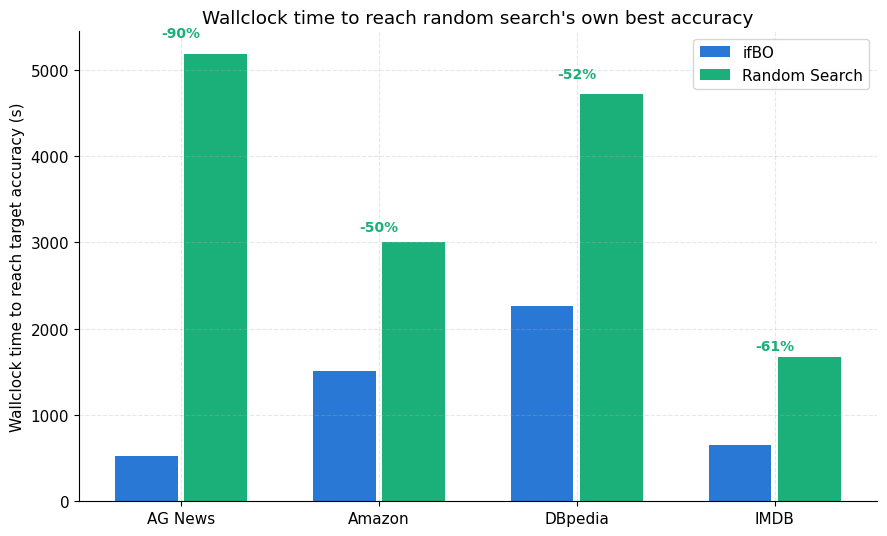

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(time_to_target_df.index))
width = 0.35

for i, (opt_key, opt_label) in enumerate(OPTIMIZERS.items()):
    vals = time_to_target_df[opt_label]
    offset = x + (i - 0.5) * width
    ax.bar(offset, vals, width=width * 0.9, color=COLORS[opt_key], label=opt_label)

for xi, (_, row) in zip(x, time_to_target_df.iterrows()):
    top = max(row["Random Search"], row["ifBO"])
    ax.text(
        xi, top + top * 0.03, f"-{row['pct_time_saved']:.0f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#1baf7a",
    )

ax.set_xticks(x)
ax.set_xticklabels(time_to_target_df.index)
ax.set_ylabel("Wallclock time to reach target accuracy (s)")
ax.set_title("Wallclock time to reach random search's own best accuracy")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Summary

In [7]:
mean_savings = time_to_target_df["pct_time_saved"].mean()
median_savings = time_to_target_df["pct_time_saved"].median()

print(f"Mean wallclock savings across the 4 datasets:   {mean_savings:.1f}%")
print(f"Median wallclock savings across the 4 datasets: {median_savings:.1f}%")
print()
print("Per-dataset range:", f"{time_to_target_df['pct_time_saved'].min():.1f}%", "to",
      f"{time_to_target_df['pct_time_saved'].max():.1f}%")

Mean wallclock savings across the 4 datasets:   63.2%
Median wallclock savings across the 4 datasets: 56.7%

Per-dataset range: 49.6% to 89.8%


**Headline number:** ifBO reaches the accuracy Random Search eventually
achieves using roughly **~60% less wallclock time**, averaged across
`ag_news`, `amazon`, `dbpedia`, and `imdb` (per-dataset savings range from
~50% to ~90% — see the table in section 3). This is based on a single seed
per optimizer/dataset in `all_results/`, not the multi-seed runs in
`seeded/`, so treat it as a directional estimate rather than a tight
statistic.